First 5 observations:
   Size  Bedrooms  Age  Price
0  1200         2   30    150
1  1500         4   10    205
2  1800         3   25    210
3  2100         5    5    295
4  2400         2   20    255

Summary Statistics:
              Size   Bedrooms        Age       Price
count    19.000000  19.000000  19.000000   19.000000
mean   2321.052632   3.421053  19.210526  277.105263
std     629.443270   1.121298  10.411420   68.054631
min    1200.000000   2.000000   5.000000  150.000000
25%    1850.000000   2.500000  10.500000  237.500000
50%    2300.000000   3.000000  18.000000  285.000000
75%    2750.000000   4.000000  27.500000  307.500000
max    3400.000000   5.000000  40.000000  420.000000
Correlation Matrix:
              Size  Bedrooms       Age     Price
Size      1.000000  0.167784 -0.326245  0.924909
Bedrooms  0.167784  1.000000 -0.436306  0.493719
Age      -0.326245 -0.436306  1.000000 -0.505999
Price     0.924909  0.493719 -0.505999  1.000000


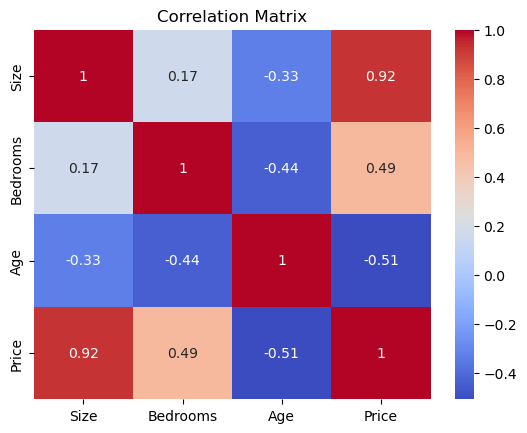

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     247.8
Date:                Sat, 02 May 2026   Prob (F-statistic):           5.35e-13
Time:                        23:12:10   Log-Likelihood:                -69.361
No. Observations:                  19   AIC:                             146.7
Df Residuals:                      15   BIC:                             150.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.4705     16.048      0.839      0.4

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Problem 1
# Loading csv file
df=pd.read_csv("Downloads/House Price.csv")
print("First 5 observations:")
print(df.head())
print("\nSummary Statistics:")
print(df.describe())

# Problem 2
# Correlation matrix
corr=df.corr()
print("Correlation Matrix:")
print(corr)
# Heatmap
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Problem 3
# defining response and explainatory variables
X=df[['Size','Bedrooms','Age']]
y=df['Price']
# Add constant (intercept)
X=sm.add_constant(X)
model=sm.OLS(y,X).fit()
print(model.summary())


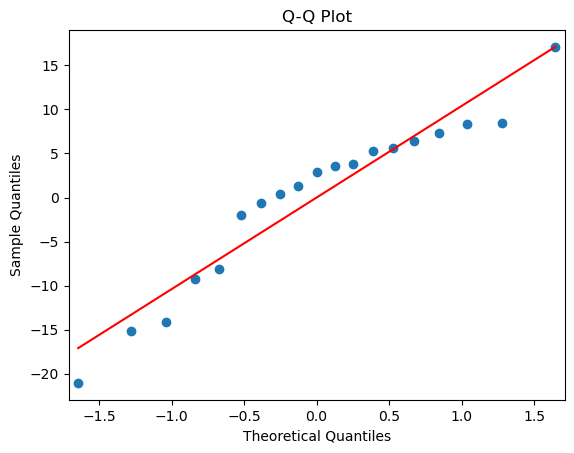

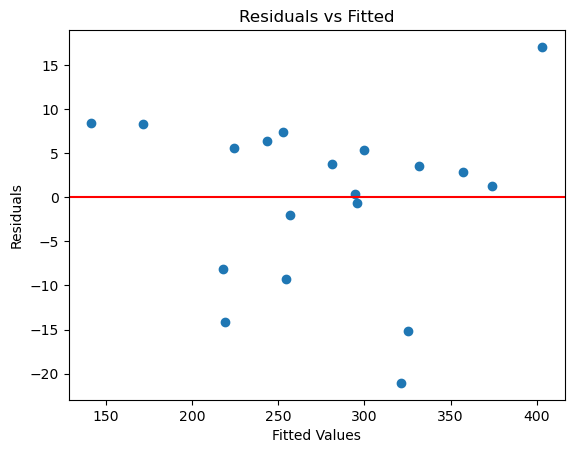


VIF Values:
    Feature        VIF
0     const  44.521401
1      Size   1.120116
2  Bedrooms   1.236227
3       Age   1.344531


In [5]:


# Problem 4
# Normality of residuals
residuals=model.resid
sm.qqplot(residuals,line='r')
plt.title("Q-Q Plot")
plt.show()

# Homoscedasticity
fitted=model.fittedvalues
plt.scatter(fitted,residuals)
plt.axhline(y=0,color='r')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Multicollinearity
vif_data=pd.DataFrame()
vif_data["Feature"]=X.columns
vif_data["VIF"]=[variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]
print("\nVIF Values:")
print(vif_data)

